<a href="https://colab.research.google.com/github/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Pietro Thompson

**Matrícula:**4052025002312

**Dataset:**
**Jogos das top 5 ligas europeias**

 Encorajamos você a usar a estrutura base deste Notebook para a construção das suas análises, já que ela contempla grande parte das sugestões do checklist no enunciado do MVP. Contudo, vale ressaltar que é necessário realizar mais etapas e análises, além das apresentadas neste notebook. É fundamental ter profundidade nas discussões e análises propostas, construindo um storytelling cativante que explore os principais conceitos e técnicas vistos nas aulas de Análise de Dados e Boas Práticas. **Este bloco de comentário com essas observações deve ser removido do seu projeto final**.

 **------**

# Descrição do Problema

O dataset utilizado contém informações sobre jogos das Top 5 Ligas Europeias de Futebol (Premier League, La Liga, Bundesliga, Serie A e Ligue 1) entre as temporadas de 2014 e 2020, totalizando 12.680 partidas.

Cada registro representa um jogo e inclui informações sobre gols marcados (total e primeiro tempo), probabilidades pré-jogo estimadas por modelos estatísticos, e odds de múltiplas casas de apostas (Bet365, Betway, Interwetten, Pinnacle, William Hill e VC Bet).

O objetivo principal desta análise é entender os padrões que determinam o resultado de uma partida de futebol, como a vantagem de jogar em casa, a distribuição de gols por liga e temporada, e a capacidade preditiva das probabilidades pré-jogo.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Times que jogam em casa têm vantagem significativa, marcando mais gols e vencendo com maior frequência?**

2. **As probabilidades pré-jogo (homeProbability, drawProbability, awayProbability) têm correlação com o resultado real da partida?**

3. **Existe diferença estatística na média de gols entre as 5 ligas analisadas?**


## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (comprimento e largura da sépala, comprimento e largura da pétala), o objetivo é prever a qual das três classes (espécies de Íris) uma determinada flor pertence.

## Seleção de Dados

O dataset foi obtido e carregado diretamente a partir de um arquivo CSV. Ele contempla partidas das **Top 5 Ligas Europeias de Futebol** (Premier League, La Liga, Bundesliga, Serie A e Ligue 1). Durante o período coberto é de 2014 a 2020, com dados de **7 temporadas completas**.

Além da base de dados principal dos jogos duas bases em arquivos CSV diferentes foram utilizadas para nomear as **Liga** e **Times** das partidas listadas.

## Atributos do Dataset

O dataset contém **12.680 instâncias** e **34 atributos**, descritos abaixo:

**Identificadores:**
- **gameID** — Identificador único do jogo
- **leagueID** — Identificador da liga (1 a 5)
- **season** — Temporada (2014 a 2020)
- **date** — Data e hora do jogo
- **homeTeamID**, **awayTeamID** — Identificadores dos times

**Variáveis de Resultado:**
- **homeGoals**, **awayGoals** — Gols marcados pelo mandante e visitante
- **homeGoalsHalfTime**, **awayGoalsHalfTime** — Gols no primeiro tempo

**Probabilidades pré-jogo:**
- **homeProbability**, **drawProbability**, **awayProbability** — Probabilidades estimadas por modelo estatístico

**Odds de casas de apostas:**
- **B365H/D/A** — Bet365 (vitória casa / empate / visitante)
- **BWH/D/A** — Betway
- **IWH/D/A** — Interwetten
- **PSH/D/A**, **PSCH/D/A** — Pinnacle
- **WHH/D/A** — William Hill
- **VCH/D/A** — VC Bet


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Configurações de visualização
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# URLs das bases de dados no GitHub
URL_GAMES   = 'https://raw.githubusercontent.com/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/refs/heads/main/games.csv'
URL_LEAGUES = 'https://raw.githubusercontent.com/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/refs/heads/main/leagues.csv'
URL_TEAMS   = 'https://raw.githubusercontent.com/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/refs/heads/main/teams.csv'


In [3]:
# carregamento do dataset (aqui, ele fica disponível nesse método)
# Carregamento das três bases de dados diretamente do GitHub
df_games   = pd.read_csv(URL_GAMES)
df_leagues = pd.read_csv(URL_LEAGUES)
df_teams   = pd.read_csv(URL_TEAMS)

In [4]:
# Merge: adicionar nome da liga à base principal
df = df_games.merge(
    df_leagues[['leagueID', 'name']].rename(columns={'name': 'leagueName'}),
    on='leagueID',
    how='left'
)

# Merge: adicionar nome do time mandante
df = df.merge(
    df_teams.rename(columns={'teamID': 'homeTeamID', 'name': 'homeTeamName'}),
    on='homeTeamID',
    how='left'
)

# Merge: adicionar nome do time visitante
df = df.merge(
    df_teams.rename(columns={'teamID': 'awayTeamID', 'name': 'awayTeamName'}),
    on='awayTeamID',
    how='left'
)

In [5]:
# primeiras linhas
df.head()

,gameID,leagueID,season,date,homeTeamID,awayTeamID,homeGoals,awayGoals,homeProbability,drawProbability,...,WHA,VCH,VCD,VCA,PSCH,PSCD,PSCA,leagueName,homeTeamName,awayTeamName
0,81,1,2015,2015-08-08 15:45:00,89,82,1,0,0.2843,0.3999,...,6.00,1.67,4.00,5.75,1.64,4.07,6.04,Premier League,Manchester United,Tottenham
1,82,1,2015,2015-08-08 18:00:00,73,71,0,1,0.3574,0.3500,...,4.00,2.00,3.50,4.20,1.82,3.88,4.70,Premier League,Bournemouth,Aston Villa
2,83,1,2015,2015-08-08 18:00:00,72,90,2,2,0.2988,0.4337,...,5.00,1.73,3.90,5.40,1.75,3.76,5.44,Premier League,Everton,Watford
3,84,1,2015,2015-08-08 18:00:00,75,77,4,2,0.6422,0.2057,...,2.70,2.00,3.40,4.33,1.79,3.74,5.10,Premier League,Leicester,Sunderland
4,85,1,2015,2015-08-08 18:00:00,79,78,1,3,0.1461,0.2159,...,2.88,2.60,3.25,3.00,2.46,3.39,3.14,Premier League,Norwich,Crystal Palace


# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA), buscamos entender a distribuição, as relações e as características das variáveis do dataset de futebol europeu.

## Engenharia de Atributos Inicial

Antes de explorar os dados, criamos algumas variáveis derivadas que serão úteis nas análises:
- **result** — resultado do jogo (Home Win, Draw, Away Win)
- **totalGoals** — total de gols na partida
- **goalDiff** — diferença de gols (mandante - visitante)
- **leagueName** — nome da liga por extenso


In [6]:
# Criação de variáveis derivadas
df['result'] = df.apply(
    lambda r: 'Home Win' if r['homeGoals'] > r['awayGoals']
    else ('Away Win' if r['awayGoals'] > r['homeGoals'] else 'Draw'),
    axis=1
)

df['totalGoals'] = df['homeGoals'] + df['awayGoals']
df['goalDiff'] = df['homeGoals'] - df['awayGoals']


df[['result', 'totalGoals', 'goalDiff', 'leagueName']].head()

,result,totalGoals,goalDiff,leagueName
0,Home Win,1,1,Premier League
1,Away Win,1,-1,Premier League
2,Draw,4,0,Premier League
3,Home Win,6,2,Premier League
4,Away Win,4,-2,Premier League


## Total e Tipo das Instâncias

O dataset Iris possui 150 instâncias (observações), com 50 instâncias para cada uma das três espécies. As quatro características de medição são de tipo numérico (float), enquanto o atributo 'species' é categórico.

In [7]:
print(f"Total de instâncias: {len(df)}")
print(f"Total de atributos: {len(df.columns)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 12680
Total de atributos: 40

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12680 entries, 0 to 12679
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gameID             12680 non-null  int64  
 1   leagueID           12680 non-null  int64  
 2   season             12680 non-null  int64  
 3   date               12680 non-null  object 
 4   homeTeamID         12680 non-null  int64  
 5   awayTeamID         12680 non-null  int64  
 6   homeGoals          12680 non-null  int64  
 7   awayGoals          12680 non-null  int64  
 8   homeProbability    12680 non-null  float64
 9   drawProbability    12680 non-null  float64
 10  awayProbability    12680 non-null  float64
 11  homeGoalsHalfTime  12680 non-null  int64  
 12  awayGoalsHalfTime  12680 non-null  int64  
 13  B365H              12675 non-null  float64
 14  B365D              12675 non-null  float

/tmp/ipykernel_4654/4261650286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='result', data=df, order=order, palette=colors)


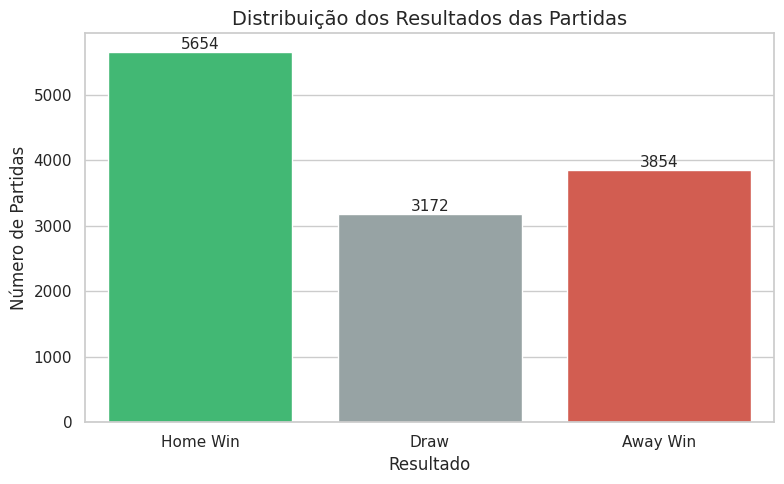

In [8]:
# Distribuição dos resultados das partidas
plt.figure(figsize=(8, 5))
order = ['Home Win', 'Draw', 'Away Win']
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
sns.countplot(x='result', data=df, order=order, palette=colors)
plt.title('Distribuição dos Resultados das Partidas', fontsize=14)
plt.xlabel('Resultado')
plt.ylabel('Número de Partidas')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

O gráfico mostra que vitórias do mandante são o resultado mais comum (≈44,6% das partidas), seguidas de vitórias do visitante (≈30,4%) e empates (≈25,0%). Isso evidencia a clássica **vantagem de jogar em casa** no futebol europeu.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [9]:
# Estatísticas descritivas das variáveis principais
df[['homeGoals', 'awayGoals', 'totalGoals', 'homeProbability', 'drawProbability', 'awayProbability']].describe()

,homeGoals,awayGoals,totalGoals,homeProbability,drawProbability,awayProbability
count,12680.000000,12680.000000,12680.000000,12680.000000,12680.000000,12680.000000
mean,1.533202,1.206625,2.739826,0.448547,0.238177,0.313276
std,1.306732,1.167718,1.670619,0.284916,0.109579,0.262446
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,2.000000,0.197450,0.163400,0.088800
50%,1.000000,1.000000,3.000000,0.428600,0.247400,0.242100
75%,2.000000,2.000000,4.000000,0.686400,0.307625,0.492725
max,10.000000,9.000000,12.000000,1.000000,0.859000,0.999700


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [12]:
# Média dos atributos de gols e probabilidades
df[['homeGoals', 'awayGoals', 'totalGoals', 'homeProbability', 'drawProbability', 'awayProbability']].describe().loc['mean'].round(3)


,mean
homeGoals,1.533
awayGoals,1.207
totalGoals,2.740
homeProbability,0.449
drawProbability,0.238
awayProbability,0.313


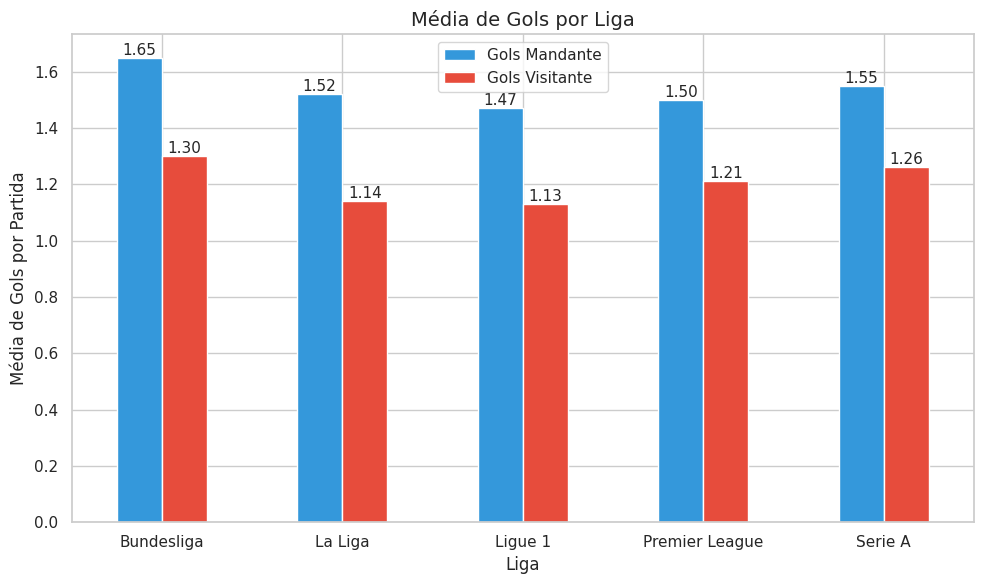

In [18]:
# Média de gols por liga
media_gols = df.groupby('leagueName')[['homeGoals', 'awayGoals']].mean().round(2)

media_gols.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c'])
plt.title('Média de Gols por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Média de Gols por Partida')
plt.xticks(rotation=0)
plt.legend(['Gols Mandante', 'Gols Visitante'])
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [20]:
# Desvio padrão dos atributos de gols
df[['homeGoals', 'awayGoals', 'totalGoals']].describe().loc['std'].round(3)

,std
homeGoals,1.307
awayGoals,1.168
totalGoals,1.671


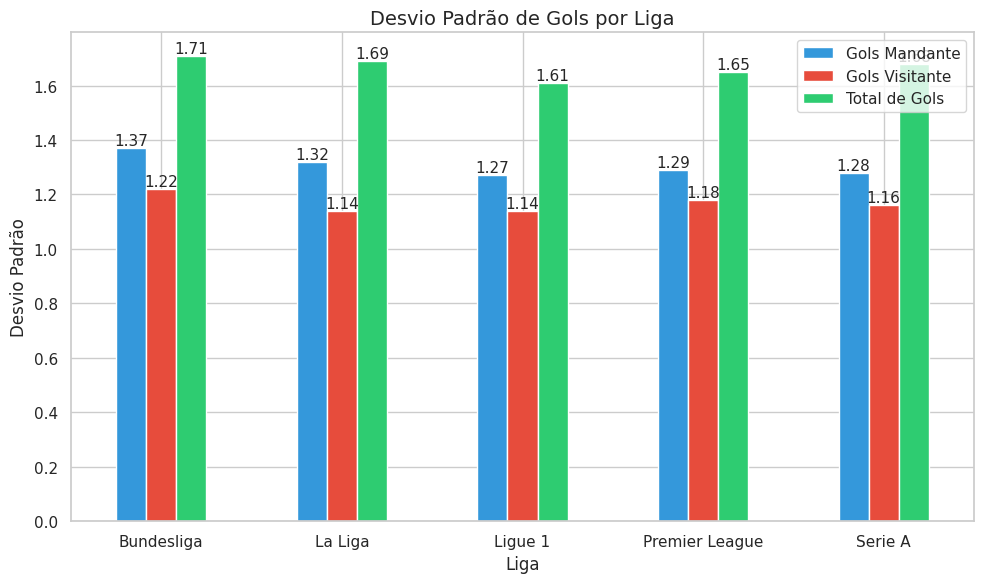

In [22]:
# Desvio padrão de gols por liga (mostra previsibilidade)
std_gols = df.groupby('leagueName')[['homeGoals', 'awayGoals', 'totalGoals']].std().round(2)

std_gols.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Desvio Padrão de Gols por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=0)
plt.legend(['Gols Mandante', 'Gols Visitante', 'Total de Gols'])
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### Total de Gols por Partida

Quantos gols acontecem em média por jogo? A distribuição é assimétrica?


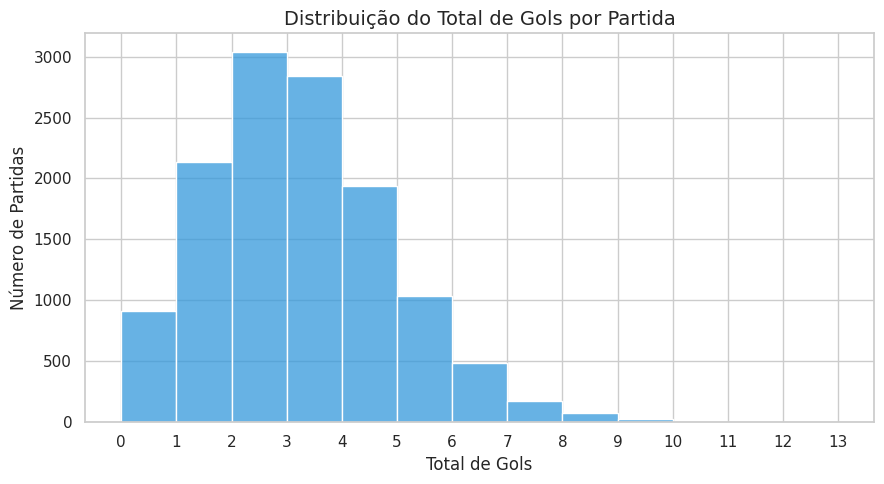

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(df['totalGoals'], bins=range(0, 14), kde=False, color='#3498db', edgecolor='white')
plt.title('Distribuição do Total de Gols por Partida', fontsize=14)
plt.xlabel('Total de Gols')
plt.ylabel('Número de Partidas')
plt.xticks(range(0, 14))
plt.tight_layout()
plt.show()


O histograma revela que a distribuição de gols segue aproximadamente uma distribuição de Poisson — com pico em 2 gols por partida e cauda longa à direita. Partidas com 0 ou 1 gol são menos frequentes do que jogos com 2-3 gols, e resultados com mais de 6 gols são raros.

### Probabilidade Pré-Jogo do Mandante

A variável **homeProbability** representa a probabilidade estimada de vitória do time da casa. Como ela se distribui?

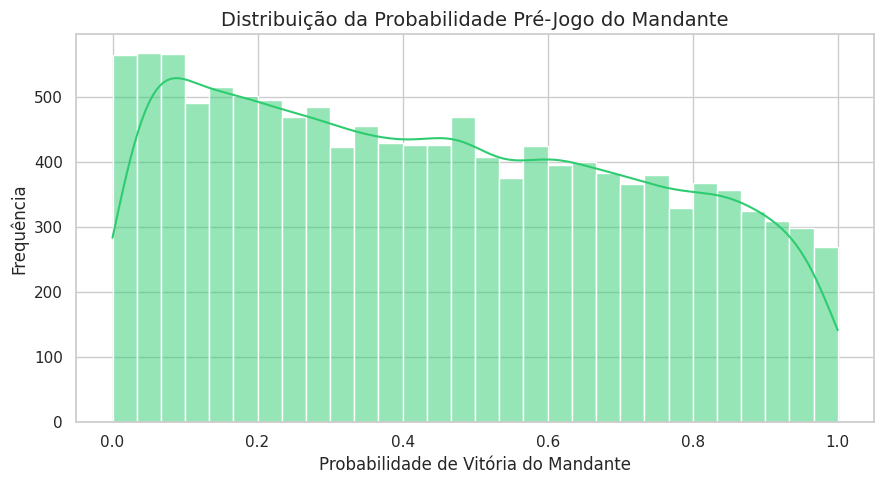

In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(df['homeProbability'], bins=30, kde=True, color='#2ecc71')
plt.title('Distribuição da Probabilidade Pré-Jogo do Mandante', fontsize=14)
plt.xlabel('Probabilidade de Vitória do Mandante')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

A distribuição da probabilidade pré-jogo do mandante apresenta uma forma levemente assimétrica à direita, com concentração entre 40% e 60% — indicando que, na maior parte das partidas, o mandante é considerado favorito ou está em equilíbrio com o visitante.

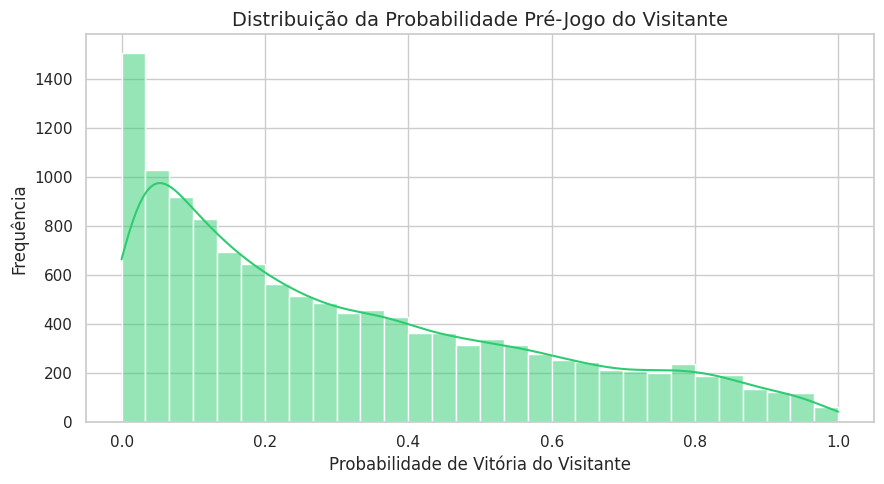

In [24]:
plt.figure(figsize=(9, 5))
sns.histplot(df['awayProbability'], bins=30, kde=True, color='#2ecc71')
plt.title('Distribuição da Probabilidade Pré-Jogo do Visitante', fontsize=14)
plt.xlabel('Probabilidade de Vitória do Visitante')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

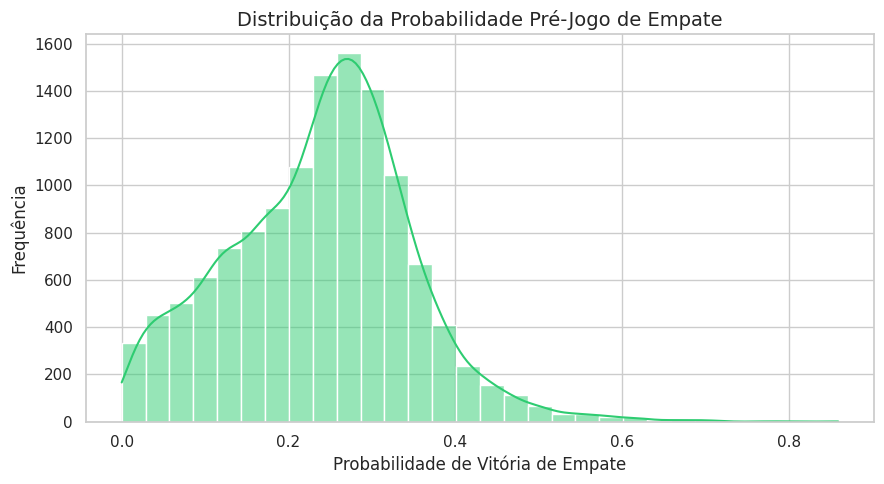

In [25]:
plt.figure(figsize=(9, 5))
sns.histplot(df['drawProbability'], bins=30, kde=True, color='#2ecc71')
plt.title('Distribuição da Probabilidade Pré-Jogo de Empate', fontsize=14)
plt.xlabel('Probabilidade de Vitória de Empate')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('species').describe()

### *petal length* por Espécie


In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Comprimento da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Comprimento da Pétala (cm)')
plt.show()

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

### *petal width* por Espécie

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title('Largura da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Largura da Pétala (cm)')
plt.show()

Quais impressões o boxplot trouxe?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.iloc[:, :4].corr()

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Iris Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
df.isnull().sum()

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (105, 4)
Dimensões de X_test: (45, 4)
Dimensões de y_train: (105,)
Dimensões de y_test: (45,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.208333           0.327586          0.416667
1           0.527778          0.083333           0.586207          0.583333
2           0.222222          0.750000           0.068966          0.083333
3           0.694444          0.500000           0.827586          0.916667
4           0.388889          0.333333           0.517241          0.500000


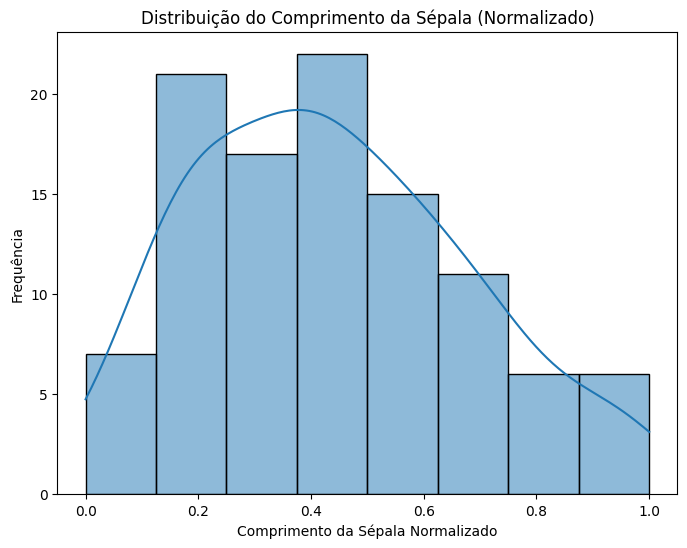

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
plt.xlabel('Comprimento da Sépala Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900459         -1.220248          -0.441986         -0.136610
1           0.380366         -1.879558           0.402829          0.380294
2          -0.900459          1.636764          -1.286801         -1.170419
3           1.078998          0.318143           1.191323          1.414103
4          -0.201827         -0.560937           0.177545          0.121842


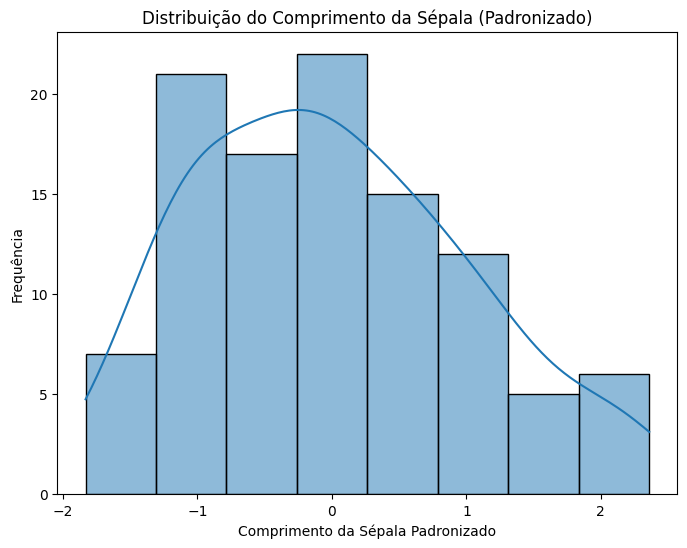

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Padronizado)')
plt.xlabel('Comprimento da Sépala Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.